In [13]:
import csv
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sklearn
import sys
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
from scipy.stats import mannwhitneyu

#from pingouin import ancova
#import pingouin as pg
from datetime import datetime, timedelta,date
warnings.filterwarnings('ignore')
from IPython.display import HTML
import seaborn as sns
from scipy.stats import mannwhitneyu
import scipy.stats as stats
import matplotlib.pyplot as plt

# These are used for the chi-squared test and post hoc testing
from scipy.stats import chi2_contingency
from itertools import combinations
from scipy.stats import fisher_exact



# Deactivate Jedi so that autocomplete is faster
%config Completer.use_jedi = False
pd.options.display.max_columns = 40
pd.options.display.min_rows = 100

In [14]:
# File updated on Oct 2 2023 in order to deal with erroneous zeroes in the cbc data
subjects = pd.read_csv("../data/aim2_exwas_data_2024-June-11.csv")

In [15]:
breastfeeding_status = pd.read_csv("../data/breastfeeding_all_timepoints_azad.csv")
breastfeeding_status = breastfeeding_status[['SubjectNumber','BF_3m_status']]
breastfeeding_status.rename(columns={'SubjectNumber':'subject_id'},inplace=True)

In [16]:
subjects = pd.merge(subjects, breastfeeding_status,how="left",on="subject_id")

In [17]:
# convert PUFA proportions to standardized z-scores

# Calculate mean and standard deviation
mean = subjects['log_C18:3n6_3m'].mean()
std = subjects['log_C18:3n6_3m'].std()

# Standardize the column and add as a new column
subjects['C18:3n6_3m_zscore'] = (subjects['log_C18:3n6_3m'] - mean) / std

# Calculate mean and standard deviation
mean = subjects['log_C22:4n6_3m'].mean()
std = subjects['log_C22:4n6_3m'].std()

# Standardize the column and add as a new column
subjects['C22:4n6_3m_zscore'] = (subjects['log_C22:4n6_3m'] - mean) / std

# Calculate mean and standard deviation
mean = subjects['log_C20:3n6_3m'].mean()
std = subjects['log_C20:3n6_3m'].std()

# Standardize the column and add as a new column
subjects['C20:3n6_3m_zscore'] = (subjects['log_C20:3n6_3m'] - mean) / std

# DHA
mean = subjects['log_C22:6n3_3m'].mean()
std = subjects['log_C22:6n3_3m'].std()
# Standardize the column and add as a new column
subjects['C22:6n3_3m_zscore'] = (subjects['log_C22:6n3_3m'] - mean) / std

# ARA
mean = subjects['log_C20:4n6_3m'].mean()
std = subjects['log_C20:4n6_3m'].std()
# Standardize the column and add as a new column
subjects['C20:4n6_3m_zscore'] = (subjects['log_C20:4n6_3m'] - mean) / std




In [18]:
# Determine the quintile for each z-score column
subjects['C20:3n6_3m_quintile'] = pd.qcut(subjects['C20:3n6_3m_zscore'], q=5, labels=[1, 2, 3, 4, 5])
subjects['C22:4n6_3m_quintile'] = pd.qcut(subjects['C22:4n6_3m_zscore'], q=5, labels=[1, 2, 3, 4, 5])
subjects['C18:3n6_3m_quintile'] = pd.qcut(subjects['C18:3n6_3m_zscore'], q=5, labels=[1, 2, 3, 4, 5])


subjects.rename(columns={'C20:3n6_3m_zscore':'C20_3n6_3m_zscore','C22:4n6_3m_zscore':'C22_4n6_3m_zscore','C18:3n6_3m_zscore':'C18_3n6_3m_zscore'},inplace=True)


In [19]:


# Determine if each sample is in the 5th quintile and assign 0, 1, or NaN
subjects['C20_3n6_3m_is_5th_quintile'] = np.where(
    subjects['C20:3n6_3m_quintile'].notna(),
    (subjects['C20:3n6_3m_quintile'] == 5).astype(int),
    np.nan
)

subjects['C22_4n6_3m_is_5th_quintile'] = np.where(
    subjects['C22:4n6_3m_quintile'].notna(),
    (subjects['C22:4n6_3m_quintile'] == 5).astype(int),
    np.nan
)

subjects['C18_3n6_3m_is_5th_quintile'] = np.where(
    subjects['C18:3n6_3m_quintile'].notna(),
    (subjects['C18:3n6_3m_quintile'] == 5).astype(int),
    np.nan
)



In [20]:
subjects.drop(columns=['C20:3n6_3m_quintile','C22:4n6_3m_quintile','C18:3n6_3m_quintile'],inplace=True)

In [21]:
from matplotlib.ticker import FuncFormatter

# Create a function to format the tick labels with decimal notation
def log_fmt(x, pos):
    if x >= 1:
        return f"{x:.1f}"
    else:
        return f"{x:.1e}"

In [23]:
vitamin_d_use_df = pd.read_csv("../data/vitamin_D_use_by_infant_all_sources_3m.csv")
subjects = subjects.merge(vitamin_d_use_df, on="subject_id", how="left")

In [24]:
# Additional breastfeeding status variables
breastfeeding_status_df = pd.read_csv("../data/breastfeeding_all_timepoints_azad.csv")

breastfeeding_status_df[breastfeeding_status_df['BF_duration_imp']==0]
for index, row in breastfeeding_status_df.iterrows():
    if row['BF_duration_imp'] == 0:
        breastfeeding_status_df.loc[index, 'never_breastfed'] = 1
    else:
        breastfeeding_status_df.loc[index, 'never_breastfed'] = 0
breastfeeding_status_df = breastfeeding_status_df[['SubjectNumber','BF_duration_imp','never_breastfed']]

In [25]:
# vitamin D derived variables

for index, row in subjects.iterrows():



    total_vitamin_d_exposures_prenatal_to_3m = 0

    if row['vitamin_D_taken_by_infant_3m']==1:
        total_vitamin_d_exposures_prenatal_to_3m = total_vitamin_d_exposures_prenatal_to_3m + 1

        
    if row['vitamin_d_intake_frequency_3m']>0.0:
        
        subjects.loc[index, 'maternal_vitamin_d_taken_3m'] = 1
    else:
        subjects.loc[index, 'maternal_vitamin_d_taken_3m'] = 0

    # Base mother prenatal vitamin D intake on those that took it at least weekly i.e. value >= 3 (i.e. 1-3 times a week, 4-6 times a week, or daily) 

    if row['vitamin_d_intake_frequency_prenatal']>2.0:
        total_vitamin_d_exposures_prenatal_to_3m = total_vitamin_d_exposures_prenatal_to_3m + 1
        subjects.loc[index, 'maternal_vitamin_d_taken_prenatal'] = 1
    else:
        subjects.loc[index, 'maternal_vitamin_d_taken_prenatal'] = 0

    if row['vitamin_d_intake_frequency_prenatal']>2.0 and row['multivitamin_intake_frequency_prenatal']>2.0:
        subjects.loc[index, 'maternal_vitamin_d_and_multivitamin_taken_prenatal'] = 1
    else:
        subjects.loc[index, 'maternal_vitamin_d_and_multivitamin_taken_prenatal'] = 0



    if row['multivitamin_intake_frequency_prenatal']>2.0:
        subjects.loc[index, 'maternal_multivitamin_taken_prenatal'] = 1
    else:
        subjects.loc[index, 'maternal_multivitamin_taken_prenatal'] = 0

    if total_vitamin_d_exposures_prenatal_to_3m==2:
        subjects.loc[index, 'vitamin_D_taken_by_infant_and_mother_3m'] = 1
    else:
        subjects.loc[index, 'vitamin_D_taken_by_infant_and_mother_3m'] = 0  
    

    subjects.loc[index, 'total_vitamin_d_exposures_prenatal_to_3m'] = total_vitamin_d_exposures_prenatal_to_3m
   



# Figure 5b with imputation

In [26]:


outcome = "asthma_5y"
visit = "5 Years"

odds_ratio_table_B = pd.DataFrame(columns=['time outcome assessed','outcome','exposure','covariate','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value','significant'])


for col in ['log_dehp_bc_rec_dust_3m','vitamin_D_taken_by_infant_3m','C20_3n6_3m_is_5th_quintile', 'C22_4n6_3m_is_5th_quintile', 'C18_3n6_3m_is_5th_quintile','num_antibiotic_courses_birth_to_1y','years_education_mother_PR18WK','daily_hand_sanitizer_used_prenatal','weekly_chem_hand_cleaner_use_mother_prenatal','weekly_oven_cleaner_use_mother_prenatal','frequency_of_use_of_oven_cleaner_3m','monthly_furniture_floor_dusting_polish_use_prenatal','site_toronto','site_edmonton','site_vancouver','older_children_in_home_3m','total_household_income_PR18WK','EBF_3m','vaginal_birth','prenatal_smoke_exposure','family_asthma_history','summer_birth','winter_birth','autumn_birth','is_male','is_caucasian']:
                    
    alternatedf = subjects.copy()
    alternatedf = alternatedf[~alternatedf[outcome].isna()]
    print("### Remove missing asthma_5y: "+str(len(alternatedf)))

    alternatedf = alternatedf[['asthma_5y','log_dehp_bc_rec_dust_3m','vitamin_D_taken_by_infant_3m','C20_3n6_3m_is_5th_quintile', 'C22_4n6_3m_is_5th_quintile', 'C18_3n6_3m_is_5th_quintile','num_antibiotic_courses_birth_to_1y','years_education_mother_PR18WK','daily_hand_sanitizer_used_prenatal','weekly_chem_hand_cleaner_use_mother_prenatal','weekly_oven_cleaner_use_mother_prenatal','frequency_of_use_of_oven_cleaner_3m','monthly_furniture_floor_dusting_polish_use_prenatal','site_toronto','site_edmonton','site_vancouver','older_children_in_home_3m','total_household_income_PR18WK','EBF_3m','vaginal_birth','prenatal_smoke_exposure','family_asthma_history','summer_birth','winter_birth','autumn_birth','is_male','is_caucasian']]


    # remove rows with missing values in the current exposure (col) being analyzed
    alternatedf = alternatedf[~alternatedf[col].isna()]
    print("Removed missing "+col+": "+str(len(alternatedf)))

    # For each iteration, fill missing values with the median, except for the current exposure (col) being analyzed

    alternatedf = alternatedf.fillna(alternatedf.median())

    asthma_cases = alternatedf[alternatedf['asthma_5y'] == 1]

    print("Number of subjects with asthma 5y in the dataset: ", len(alternatedf[alternatedf["asthma_5y"]==1]))
    # Fit ANCOVA model with interaction term
    model = sm.formula.logit('asthma_5y ~  log_dehp_bc_rec_dust_3m + vitamin_D_taken_by_infant_3m +  C20_3n6_3m_is_5th_quintile + C22_4n6_3m_is_5th_quintile + C18_3n6_3m_is_5th_quintile + daily_hand_sanitizer_used_prenatal + weekly_chem_hand_cleaner_use_mother_prenatal + weekly_oven_cleaner_use_mother_prenatal +  frequency_of_use_of_oven_cleaner_3m + monthly_furniture_floor_dusting_polish_use_prenatal + num_antibiotic_courses_birth_to_1y + site_toronto + site_edmonton + site_vancouver+ older_children_in_home_3m + total_household_income_PR18WK + years_education_mother_PR18WK + EBF_3m + vaginal_birth + prenatal_smoke_exposure   + family_asthma_history + summer_birth + winter_birth + autumn_birth  + is_male + is_caucasian', data=alternatedf).fit()

        # Print model summary
    print(model.summary())
                        

    if col !=outcome:

        odds_ratios = pd.DataFrame(
                                                {
                                                    "OR": model.params,
                                                    "Lower CI": model.conf_int()[0],
                                                    "Upper CI": model.conf_int()[1]
                                                }
                                            )
        odds_ratios = np.exp(odds_ratios)

        odds_ratios['P-value'] = round(model.pvalues,4)

        odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
        odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
        odds_ratios['OR'] = round(odds_ratios['OR'],2)

        odds_ratios = odds_ratios.loc[col]   
        significant_effect_row = odds_ratios.to_dict()
        significant_effect_row['total cases']=len(asthma_cases)
        if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                significant_effect_row['significant']="*"
        elif significant_effect_row['P-value']<0.01:
            significant_effect_row['significant']="**"
        else:
            significant_effect_row['significant']=""

        significant_effect_row['outcome']= outcome
                  
                        
        significant_effect_row['exposure']=col
        total_exposures = alternatedf[alternatedf[col]!=0]
        total_cases = alternatedf[alternatedf[outcome]==1]
        total_cases_exposed = total_cases[total_cases[col]!=0]
                       
        significant_effect_row['total exposures']=len(total_exposures)
        significant_effect_row['total cases with exposure']=len(total_cases_exposed)

        if "_8y" in outcome:                         
            significant_effect_row['time outcome assessed']='8 years'   
        if "_5y" in outcome:                         
            significant_effect_row['time outcome assessed']='5 years'
        if "_3y" in outcome:                         
            significant_effect_row['time outcome assessed']='3 years'
        if "_1y" in outcome:                         
            significant_effect_row['time outcome assessed']='1 year'
                    
                    
        significant_effect_row['total children']=len(alternatedf)
        asthma_cases = alternatedf[alternatedf['asthma_5y'] == 1]
        significant_effect_row['total cases']=len(asthma_cases)

        odds_ratio_table_B.loc[len(odds_ratio_table_B)] = significant_effect_row



        

### Remove missing asthma_5y: 2431
Removed missing log_dehp_bc_rec_dust_3m: 593
Number of subjects with asthma 5y in the dataset:  129
Optimization terminated successfully.
         Current function value: 0.431523
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              asthma_5y   No. Observations:                  593
Model:                          Logit   Df Residuals:                      566
Method:                           MLE   Df Model:                           26
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                  0.1761
Time:                        20:05:34   Log-Likelihood:                -255.89
converged:                       True   LL-Null:                       -310.60
Covariance Type:            nonrobust   LLR p-value:                 3.333e-12
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------

In [27]:
odds_ratio_table_B['exposure'] = odds_ratio_table_B['exposure'].replace('summer_birth','zCovariate - Season of birth: Summer').replace('winter_birth','zCovariate - Season of birth: Winter').replace('autumn_birth','zCovariate - Season of birth: Autumn')
odds_ratio_table_B['exposure'] = odds_ratio_table_B['exposure'].replace('site_toronto','zCovariate - Site_toronto').replace('site_vancouver','zCovariate - Site_vancouver').replace('site_edmonton','zCovariate - Site_edmonton')
odds_ratio_table_B['exposure'] = odds_ratio_table_B['exposure'].replace('weekly_chem_hand_cleaner_use_mother_prenatal','cleaning_weekly_chem_hand_cleaner_use_mother_prenatal').replace('weekly_oven_cleaner_use_mother_prenatal','cleaning_weekly_oven_cleaner_use_mother_prenatal').replace('daily_hand_sanitizer_used_prenatal','cleaning_daily_hand_sanitizer_used_prenatal').replace('frequency_of_use_of_oven_cleaner_3m','cleaningz_frequency_of_use_of_oven_cleaner_3m').replace('num_antibiotic_courses_birth_to_1y','antibiotic_courses_birth_to_1y')
odds_ratio_table_B['exposure'] = odds_ratio_table_B['exposure'].replace('years_education_mother_PR18WK','zCovariate - education_years_education_mother_PR18WK')

odds_ratio_table_B['exposure'] = odds_ratio_table_B['exposure'].replace('vaginal_birth','zCovariate - vaginal_birth')
odds_ratio_table_B['exposure'] = odds_ratio_table_B['exposure'].replace('prenatal_smoke_exposure','zCovariate - prenatal_smoke_exposure')
odds_ratio_table_B['exposure'] = odds_ratio_table_B['exposure'].replace('family_asthma_history','yCovariate - family_asthma_history')
odds_ratio_table_B['exposure'] = odds_ratio_table_B['exposure'].replace('is_male','yCovariate - is_male')
odds_ratio_table_B['exposure'] = odds_ratio_table_B['exposure'].replace('is_caucasian','zCovariate - is_caucasian')

odds_ratio_table_B['exposure'] = odds_ratio_table_B['exposure'].replace('total_household_income_PR18WK','zCovariate - total_household_income_PR18WK')
odds_ratio_table_B['exposure'] = odds_ratio_table_B['exposure'].replace('older_children_in_home_3m','zCovariate - older_children_in_home_3m')
odds_ratio_table_B['exposure'] = odds_ratio_table_B['exposure'].replace('EBF_3m','zCovariate - EBF_3m')

odds_ratio_table_B['exposure'] = odds_ratio_table_B['exposure'].replace('monthly_furniture_floor_dusting_polish_use_prenatal','cleaning_monthly_furniture_floor_dusting_polish_use_prenatal')
#odds_ratio_table_B = odds_ratio_table_B[odds_ratio_table_B['exposure']!='is_caucasian']

odds_ratio_table_B

,time outcome assessed,outcome,exposure,covariate,total children,total cases,total exposures,total cases with exposure,OR,Lower CI,Upper CI,P-value,significant
0,5 years,asthma_5y,log_dehp_bc_rec_dust_3m,NaN,593,129,593,129,1.92,1.40,2.64,0.0001,**
1,5 years,asthma_5y,vitamin_D_taken_by_infant_3m,NaN,2431,168,1418,114,1.30,0.89,1.90,0.1775,
2,5 years,asthma_5y,C20_3n6_3m_is_5th_quintile,NaN,983,112,186,28,0.91,0.50,1.66,0.7532,
3,5 years,asthma_5y,C22_4n6_3m_is_5th_quintile,NaN,983,112,183,33,1.92,1.09,3.37,0.0233,*
4,5 years,asthma_5y,C18_3n6_3m_is_5th_quintile,NaN,983,112,187,29,1.48,0.87,2.53,0.1462,
5,5 years,asthma_5y,antibiotic_courses_birth_to_1y,NaN,2431,168,658,65,1.20,1.05,1.37,0.0061,**
6,5 years,asthma_5y,zCovariate - education_years_education_mother_...,NaN,2352,163,2352,163,0.98,0.92,1.04,0.4561,
7,5 years,asthma_5y,cleaning_daily_hand_sanitizer_used_prenatal,NaN,2421,167,362,38,1.63,1.07,2.50,0.0232,*
8,5 years,asthma_5y,cleaning_weekly_chem_hand_cleaner_use_mother_p...,NaN,2325,158,64,17,2.64,1.27,5.51,0.0095,**
9,5 years,asthma_5y,cleaning_weekly_oven_cleaner_use_mother_prenatal,NaN,2325,158,51,12,2.31,1.01,5.26,0.0473,*


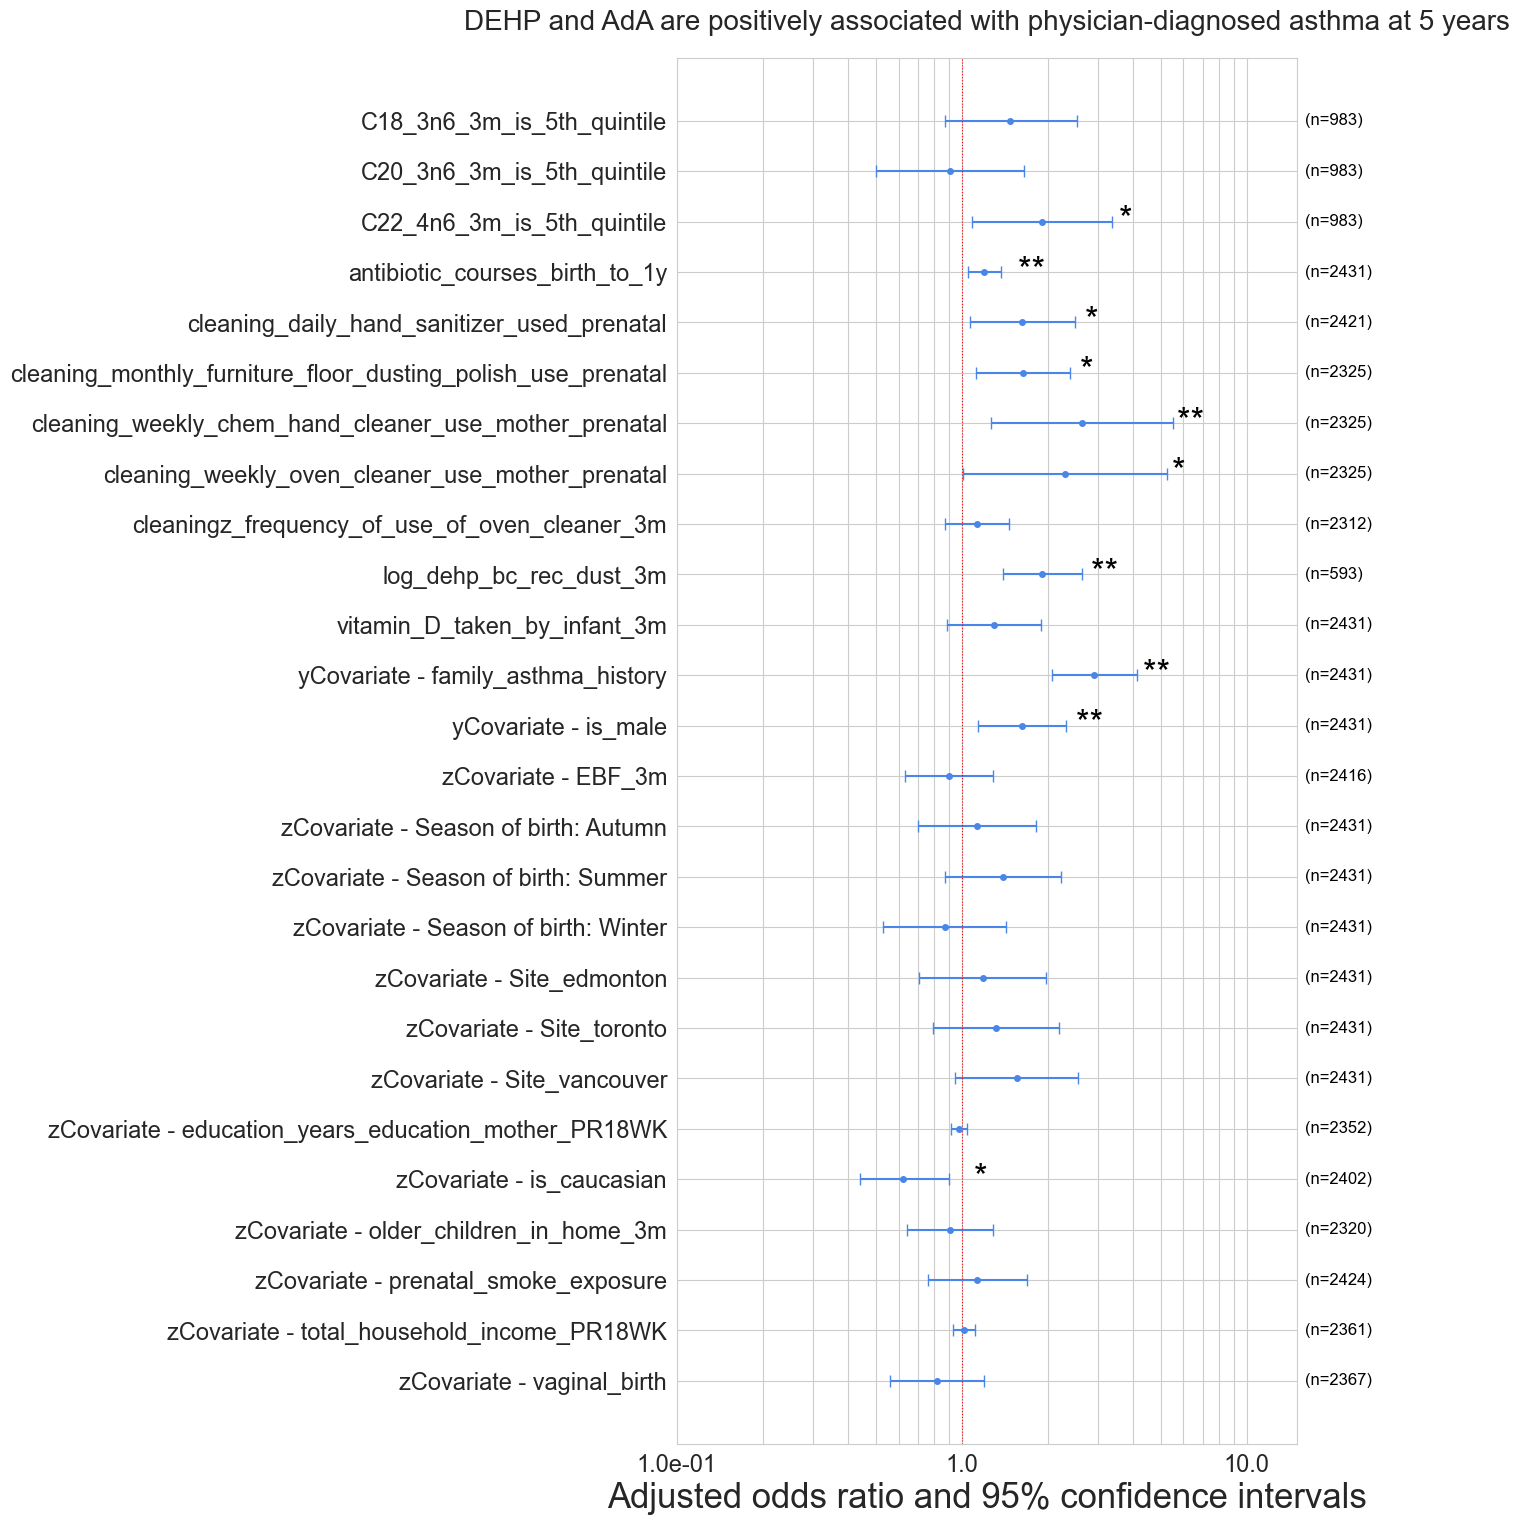

In [28]:

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(8,18))
plt.title("DEHP and AdA are positively associated with physician-diagnosed asthma at 5 years",fontsize=20, pad=20)
odds_ratio_table_B.sort_values(by=["covariate","exposure"],inplace=True)
for idx, row in odds_ratio_table_B.iloc[::-1].iterrows():

    if row['outcome']=='asthma_5y':    
        
        #if row['time outcome assessed']=='5 years' and (row['P-value']<0.05) and row['exposure'] !='Site_vancouver':
        if row['time outcome assessed']=='5 years':
 
            ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
            if 1:
                label = ""

                
                plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='#4a86e8', capsize=4, linestyle='None', linewidth=1.5, marker="o", markersize=4, mfc="#4a86e8", mec="#4a86e8")
                 #if row['male_or_female']=='All':
                #    plt.errorbar(x=[row['OR']], y=[row['exposure']+ row['male_or_female']], xerr=ci, ecolor='magenta', capsize=5, linestyle='None', linewidth=3, marker="o", markersize=6, mfc="magenta", mec="magenta")
                
            
                if row['P-value']<0.01:
                    #label = str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure']) + ", p="+str(row['P-value'])+" *"
                    label = "** " 
                elif row['P-value']<0.05:
                    label = "*  "
                else:
                    label = "   "

                label2 = "(n=" + str(row['total children']) + ")"
                # Add text to the right of the error bar
                plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=25)
                plt.text(16, row['exposure'], f'{label2}', color='black', va='center', fontsize=12)

plt.xscale('log',base=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')
plt.xlim(0.1,15)
#plt.ylim(-0.5, 6.5)
plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=17)
plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=25)


plt.show()